<a href="https://colab.research.google.com/github/pablillo77/geometric-characterization-of-AAA-with-PCA/blob/main/PCA_Shape_Modes_public.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/pablillo77/mscfava/blob/main/PCA_Shape_Modes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo estadístico de forma de AAA mediante PCA

**Tesis de Maestría — Caracterización geométrica 3D de aneurismas de aorta abdominal (AAA) en población local.**

La idea central: cada aneurisma se resume en un conjunto de mediciones
geométricas (diámetros, longitudes, ángulos, etc.). En vez de mirar esas
variables una por una, buscamos las **direcciones principales de variación de
la forma** — combinaciones de mediciones que varían juntas entre pacientes.
Eso es exactamente lo que encuentra el **PCA**, y cada componente principal se
interpreta luego como un **modo de forma** (*shape mode*): una manera concreta
en que la geometría del aneurisma cambia a lo largo de la población.

El pipeline:

1. **Cargar** las mediciones geométricas (una fila por paciente)
2. **Estandarizar** las variables (están en unidades distintas: mm, grados, ratios)
3. **PCA** sobre los datos estandarizados → autovalores (varianza por modo) y
   autovectores (direcciones de forma)
4. **Varianza explicada** → cuántos modos hacen falta para describir la población
5. **Proyecciones**: cada paciente como un punto en el espacio de formas
6. **Agrupamiento** (K-Means y jerárquico) → grupos morfológicos de aneurismas
7. **Modos de forma**: reconstruir formas sintéticas en `media ± k·√λ·v` para
   *interpretar geométricamente* qué representa cada componente

## 1. Datos y preparación

Las mediciones viven en una planilla de Google Sheets (una fila por paciente,
indexada por el ID de paciente). Nos quedamos con las columnas geométricas
—hasta `Beta`— y descartamos las que no describen la forma (identificadores y
un par de ángulos/variables auxiliares que no entran en el modelo).

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
import scipy.cluster.hierarchy as sch
import plotly.express as px

In [ ]:
# Cargar la planilla desde Google Sheets (hoja "DatosLimpios")
ID_planilla = "1_-l829ejbdEMCD9XwrDsxcei9nvGnwKE0lh0XZ2jLOQ"
URL = f"https://docs.google.com/spreadsheets/d/{ID_planilla}/gviz/tq?tqx=out:csv&sheet="

df_mediciones = pd.read_csv(URL + "DatosLimpios")
df_mediciones.index = df_mediciones["Paciente"]

In [ ]:
# Nos quedamos con las variables geométricas (hasta 'Beta') y descartamos
# identificadores y variables que no entran en el modelo de forma.
df = df_mediciones.loc[:, :"Beta"].drop(
    columns=["Paciente", "dc", "Ángulo Aneurisma", "Ángulo renal", "H"]
)

print(f"{df.shape[0]} pacientes x {df.shape[1]} variables geométricas")
df.describe().T

26 pacientes x 15 variables geométricas


,count,mean,std,min,25%,50%,75%,max
Dneck1,26.0,2.337308,0.418115,1.52,2.0900,2.285,2.6125,3.14
Dneck2,26.0,2.895769,0.391696,2.33,2.6400,2.760,3.1850,3.82
Dmax,26.0,5.730000,0.840376,4.09,5.1175,5.665,6.2900,7.31
Dmin,26.0,3.006538,1.073812,1.73,2.2850,2.620,3.4175,5.83
Dsellado1,26.0,1.553846,0.514355,0.70,1.1250,1.470,1.9350,2.70
Dsellado2,26.0,1.536538,0.517579,0.82,1.2000,1.440,1.6850,3.20
Lneck,26.0,3.157308,1.165437,1.50,2.4300,2.830,3.6500,6.54
Hneck,26.0,2.567692,0.967852,0.80,1.9650,2.470,3.1525,4.80
L,26.0,9.411923,2.269959,6.44,8.2200,8.985,9.6700,17.20
L1,26.0,6.599231,3.566974,3.38,4.6500,5.845,7.1900,22.00


## 2. Estandarización y PCA

Las variables están en unidades distintas (un diámetro en mm y un ángulo en
grados no son comparables en crudo), así que primero **estandarizamos**: a cada
variable le restamos su media y la dividimos por su desvío. Con esto el PCA
trabaja sobre la **matriz de correlación** y ninguna variable domina solo por
tener números más grandes.

Del PCA nos importan dos cosas:

- `pca.components_[j]` → el **autovector** del modo *j*: la dirección de forma
  (cuánto pesa cada variable geométrica en ese modo)
- `pca.explained_variance_[j]` = **autovalor** λⱼ → cuánta varianza captura ese
  modo. Su raíz `√λⱼ` es el desvío a lo largo del modo, y la vamos a necesitar
  para reconstruir los *shape modes* en la sección 7.

In [ ]:
# Estandarización (una sola vez; scaler queda guardado para revertir después)
scaler = StandardScaler(with_mean=True, with_std=True)
scaled_data = scaler.fit_transform(df)

# PCA sobre los datos estandarizados
pca = PCA()
pca.fit(scaled_data)

eigenvalues       = pca.explained_variance_        # varianza por componente (lambda_i)
sqrt_eigenvalues  = np.sqrt(eigenvalues)           # desvío por componente (sqrt de lambda_i)
explained_ratio   = pca.explained_variance_ratio_  # fracción de varianza por componente

## 3. ¿Cuántos modos hacen falta?

El *scree plot* muestra la varianza que aporta cada componente (izquierda) y la
acumulada (derecha). Se busca el **codo**: el punto a partir del cual sumar
componentes ya no agrega forma real, solo ruido. La línea de referencia marca
el 80% de varianza acumulada, un umbral habitual para decidir cuántos modos
retener.

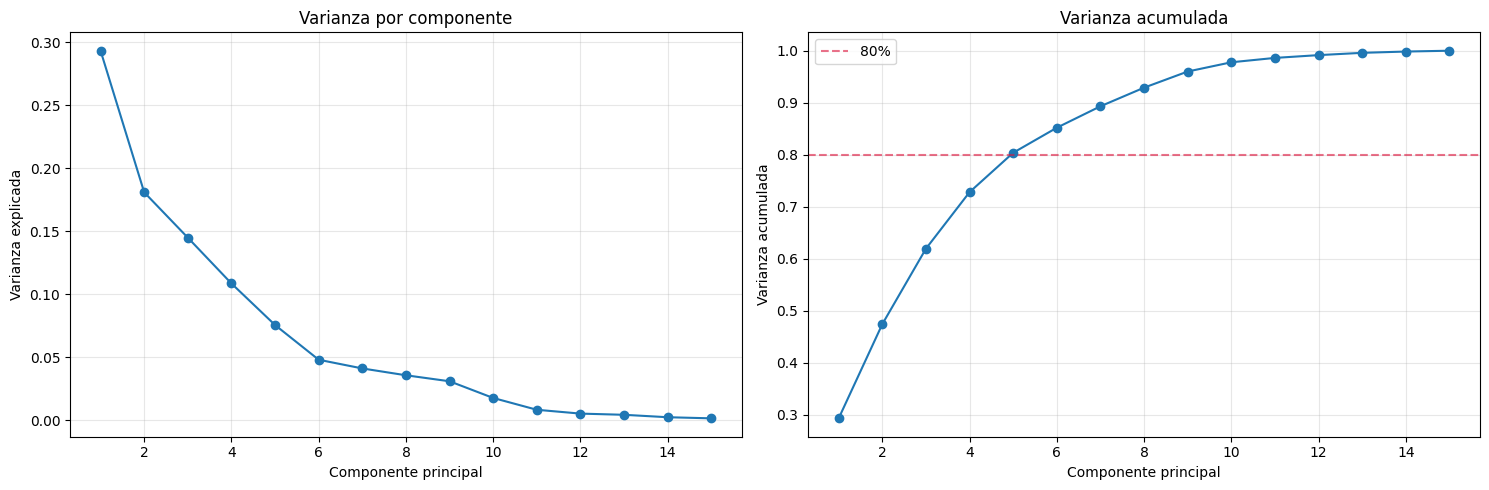

  PC1    29.3%   acumulada  29.3%
  PC2    18.1%   acumulada  47.5%
  PC3    14.5%   acumulada  62.0%
  PC4    10.9%   acumulada  72.8%
  PC5     7.6%   acumulada  80.4%
  PC6     4.8%   acumulada  85.2%
  PC7     4.1%   acumulada  89.3%
  PC8     3.6%   acumulada  92.9%
  PC9     3.1%   acumulada  96.0%
  PC10    1.8%   acumulada  97.8%
  PC11    0.8%   acumulada  98.6%
  PC12    0.5%   acumulada  99.2%
  PC13    0.4%   acumulada  99.6%
  PC14    0.2%   acumulada  99.8%
  PC15    0.2%   acumulada 100.0%


In [ ]:
cumulative = np.cumsum(explained_ratio)
n = len(explained_ratio)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(range(1, n + 1), explained_ratio, marker="o")
ax1.set_xlabel("Componente principal")
ax1.set_ylabel("Varianza explicada")
ax1.set_title("Varianza por componente")
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, n + 1), cumulative, marker="o")
ax2.axhline(0.80, color="crimson", ls="--", alpha=0.6, label="80%")
ax2.set_xlabel("Componente principal")
ax2.set_ylabel("Varianza acumulada")
ax2.set_title("Varianza acumulada")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for i in range(n):
    print(f"  PC{i+1:<2d}  {explained_ratio[i]*100:5.1f}%   acumulada {cumulative[i]*100:5.1f}%")

## 4. Proyecciones: cada paciente en el espacio de formas

Proyectar los datos sobre los componentes convierte a cada paciente en un punto
cuyas coordenadas (PC1, PC2, PC3, ...) son sus *scores* de forma: cuánto se
aleja del promedio a lo largo de cada modo. Este es el espacio donde después
buscamos grupos.

In [ ]:
proyecciones = pd.DataFrame(
    pca.transform(scaled_data),
    index=df.index,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
)
proyecciones

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
Paciente,,,,,,,,,,,,,,,
AE1,-1.206688,1.092135,0.259964,0.238342,-0.709691,-0.297699,-0.331207,-1.404780,-0.796429,0.135600,0.023530,0.198068,-0.017045,-0.349014,0.122002
AE2,0.890124,0.389048,-0.097724,1.314314,-1.820896,0.141511,-0.613387,-0.589574,0.161436,-0.882922,0.499291,-0.016175,0.017316,0.133027,0.068208
FJ,3.008000,-0.582690,-1.109591,-0.141812,-2.066451,0.018175,0.177060,-0.389829,0.471389,1.113909,0.418631,0.342530,0.230813,-0.116788,0.114934
AD,0.123254,0.068129,-2.312856,2.169414,0.300335,-1.098106,-0.505658,0.513625,-0.631014,-0.131669,0.660907,0.010315,-0.407504,0.027384,-0.228922
BG,-1.104994,1.869934,0.993848,0.818405,0.031889,-0.147967,0.968535,-0.479241,0.229635,1.092432,-0.130849,-0.402468,-0.220057,0.109937,-0.079521
MA,0.043893,-0.751395,0.231942,-0.591470,1.017935,-1.325523,-0.649621,0.394615,-1.218430,0.787811,-0.096730,0.198475,-0.081598,0.394105,-0.038724
RM,0.619921,-0.325751,-1.752452,-2.272445,-1.126079,-0.019502,1.265165,0.828348,-0.266770,0.425499,-0.032688,-0.493912,0.100119,-0.080556,0.153788
CJ1,6.824718,4.443917,0.732877,-0.226318,1.910969,0.201636,-0.111280,-0.027559,-0.419247,-0.293739,0.174669,-0.010854,0.152845,-0.059772,0.016965
CJ2,0.269559,1.518105,0.735839,2.350447,-0.660277,-0.289303,0.868503,0.743612,0.671657,-0.317464,-0.439365,0.232149,0.045204,0.053031,-0.035040


## 5. Agrupamiento por K-Means en el espacio de formas

Buscamos grupos de aneurismas con forma parecida. K-Means agrupa a los
pacientes según sus coordenadas PCA; el scatter 3D interactivo (PC1-PC2-PC3)
permite rotar y ver cómo se separan.

> El número de grupos `N_CLUSTERS` es un parámetro del estudio — ajustalo al
> valor que definas por el codo del dendrograma / criterio clínico.

In [ ]:
N_CLUSTERS = 4

# Clustering sobre las proyecciones PCA (solo las columnas PC, sin la etiqueta)
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=0, n_init=10)
proyecciones["cluster"] = kmeans.fit_predict(proyecciones)

fig = px.scatter_3d(
    proyecciones, x="PC1", y="PC2", z="PC3",
    color="cluster",
    hover_name=proyecciones.index,
    title="Pacientes agrupados (K-Means) en el espacio de componentes principales",
    width=1000, height=800,
)
fig.update_traces(marker=dict(size=6), text=proyecciones.index, textposition="top center")
fig.show()

## 6. Agrupamiento jerárquico (dendrograma)

Como contraste con K-Means, el clustering jerárquico (enlace de Ward, distancia
euclídea) no necesita fijar de antemano el número de grupos: el **dendrograma**
muestra cómo se van fusionando los pacientes y a qué altura conviene cortar.

> Nota metodológica: tanto el dendrograma como el agrupamiento se calculan
> sobre los **datos estandarizados** (`scaled_data`), para que ambos usen la
> misma escala. En la versión original el `AgglomerativeClustering` se ajustaba
> sobre `df` sin estandarizar, inconsistente con el dendrograma — acá quedó
> unificado sobre `scaled_data`.

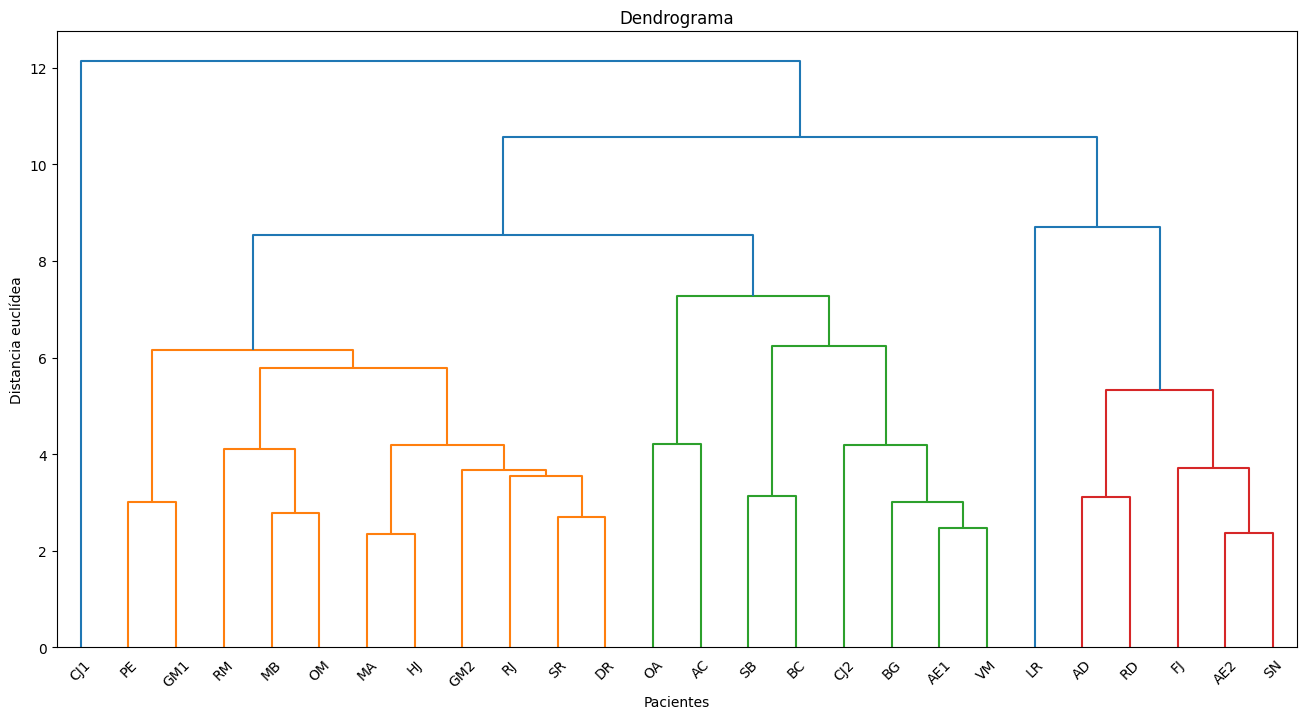

In [ ]:
plt.figure(figsize=(16, 8))
sch.dendrogram(
    sch.linkage(scaled_data, method="ward", metric="euclidean"),
    orientation="top",
    labels=df.index.tolist(),
)
plt.title("Dendrograma")
plt.xlabel("Pacientes")
plt.ylabel("Distancia euclídea")
plt.show()

In [ ]:
# Cortamos en N_CLUSTERS grupos. 'metric' reemplaza al antiguo 'affinity'
# (renombrado en scikit-learn 1.2+). Ajustado sobre scaled_data, igual que el dendrograma.
hc = AgglomerativeClustering(n_clusters=N_CLUSTERS, metric="euclidean", linkage="ward")
y_hc = hc.fit_predict(scaled_data)

df_hc = df.copy()
df_hc["Cluster"] = y_hc
df_hc

,Dneck1,Dneck2,Dmax,Dmin,Dsellado1,Dsellado2,Lneck,Hneck,L,L1,L2,Hb,d,Alfa,Beta,Cluster
Paciente,,,,,,,,,,,,,,,,
AE1,2.97,2.69,5.34,1.78,1.37,1.47,3.70,3.04,8.20,6.20,6.40,7.83,7.20,22.5,17.8,0
AE2,2.94,3.20,5.10,2.82,0.98,1.41,3.03,2.43,10.20,6.70,5.24,8.70,9.70,31.0,51.0,2
FJ,2.27,3.05,7.12,2.27,1.00,1.20,2.28,2.19,13.00,7.20,5.11,8.60,11.40,46.0,52.0,2
AD,2.65,3.37,5.95,1.85,1.32,1.20,1.50,1.15,7.60,7.16,8.80,7.30,7.50,9.4,58.0,2
BG,2.65,3.29,5.96,2.42,1.37,1.54,4.40,4.20,7.90,6.30,8.70,7.20,7.70,16.0,11.0,0
MA,2.22,2.52,6.23,2.22,2.40,1.81,2.68,2.28,9.40,5.67,8.67,8.20,8.54,13.4,37.4,0
RM,1.53,2.40,6.94,2.48,1.08,1.25,3.43,2.53,8.97,5.40,5.30,5.60,8.37,34.2,52.3,0
CJ1,2.41,2.72,7.31,5.11,0.70,0.82,3.95,3.51,13.50,22.00,16.60,14.96,12.50,28.4,55.2,3
CJ2,2.87,3.82,5.69,3.47,1.49,1.25,4.16,3.55,9.23,8.70,7.60,7.34,7.93,19.8,46.5,0


## 7. Perfil morfológico de cada grupo

Un boxplot por variable, separado por cluster, muestra qué distingue a cada
grupo: qué diámetros o ángulos son sistemáticamente mayores o menores. Así los
clusters dejan de ser un número y pasan a tener una lectura anatómica.

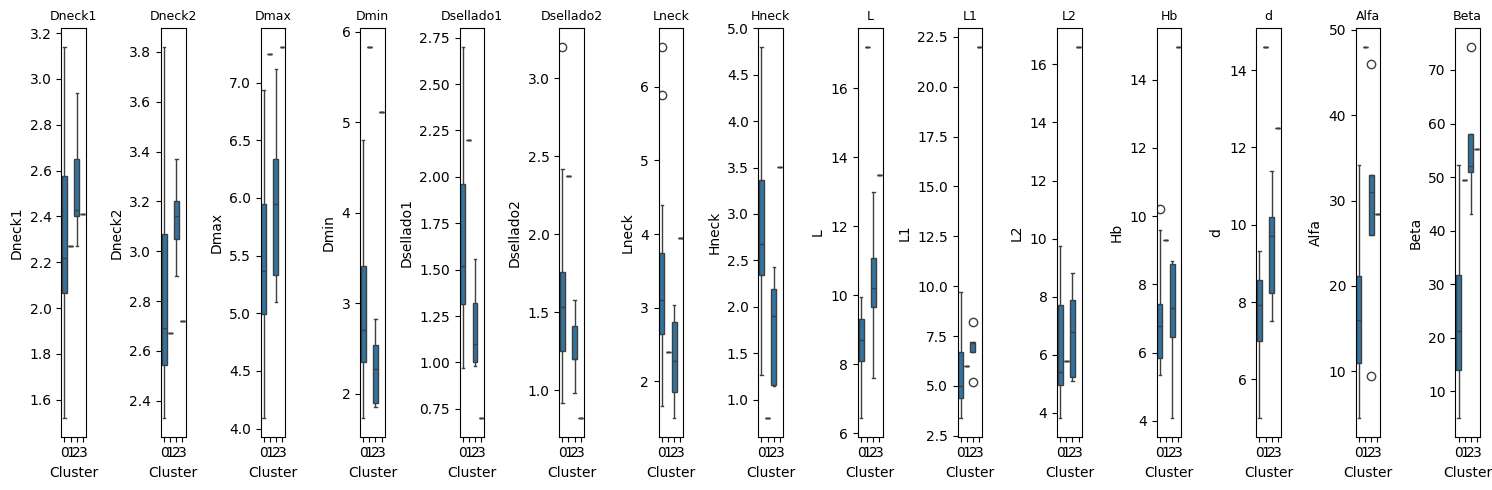

In [ ]:
feature_cols = df_hc.columns[:-1]   # todas menos 'Cluster'

fig, axes = plt.subplots(1, len(feature_cols), figsize=(15, 5))
for ax, column in zip(axes, feature_cols):
    sns.boxplot(x="Cluster", y=column, data=df_hc, ax=ax)
    ax.set_title(column, fontsize=9)

plt.tight_layout()
plt.show()

## 8. Modos de forma (*shape modes*)

Esta es la interpretación geométrica del modelo. Un componente principal es una
dirección abstracta; para *ver* qué significa, reconstruimos formas sintéticas
desplazándonos a lo largo de él desde la forma media:

$$\text{forma}(j, k) = \bar{x} + k \cdot \sqrt{\lambda_j} \cdot v_j \cdot \sigma$$

donde $\bar{x}$ y $\sigma$ son la media y el desvío de cada variable, $v_j$ el
autovector del modo *j*, $\sqrt{\lambda_j}$ el desvío a lo largo de ese modo, y
$k$ el número de desvíos (acá $k = \pm 2$). Comparar `media − 2σ` contra
`media + 2σ` de un modo dice, variable por variable, cómo cambia la geometría
del aneurisma al recorrer ese modo.

> Optimización: la versión original sumaba la variación a los 28 pacientes, luego
> revertía la estandarización y promediaba (`describe().mean()`). El resultado es
> idéntico a la fórmula directa de arriba (verificado), así que acá se calcula de
> forma directa — una fila por variable, sin pasar por las 28. Además, las
> etiquetas ahora dicen `±2σ` (antes decían `1std` aunque `k=±2`), y se omiten las
> columnas de desvío del resumen porque sumar un vector constante no cambia el
> desvío (eran solo el σ original repetido).

In [ ]:
K = 2   # numero de desvios estandar a recorrer en cada modo (+/- K)
N_MODES = 3   # cuantos modos de forma reconstruir (PC1..PC3)

mu    = scaler.mean_
sigma = scaler.scale_

resumen = pd.DataFrame({"media": mu}, index=df.columns)
for j in range(N_MODES):
    paso = sqrt_eigenvalues[j] * pca.components_[j, :] * sigma
    resumen[f"PC{j+1} -{K}σ"] = mu - K * paso
    resumen[f"PC{j+1} +{K}σ"] = mu + K * paso

resumen.round(2)

,media,PC1 -2σ,PC1 +2σ,PC2 -2σ,PC2 +2σ,PC3 -2σ,PC3 +2σ
Dneck1,2.34,2.34,2.33,2.23,2.45,2.09,2.58
Dneck2,2.90,2.90,2.89,2.85,2.94,2.82,2.98
Dmax,5.73,4.46,7.00,6.07,5.39,5.99,5.47
Dmin,3.01,1.86,4.15,3.56,2.45,2.13,3.88
Dsellado1,1.55,1.81,1.30,2.13,0.98,0.95,2.16
Dsellado2,1.54,1.66,1.41,2.18,0.90,0.85,2.22
Lneck,3.16,3.58,2.74,1.85,4.46,1.62,4.69
Hneck,2.57,3.12,2.02,1.16,3.97,1.57,3.57
L,9.41,5.49,13.34,10.68,8.14,8.61,10.22
L1,6.60,1.99,11.21,2.25,10.95,6.96,6.24
